# AE Reconstruction Sanity Check

Loads trained AE checkpoints, runs Splatt3r on a DROID-100 sample,
encodes/decodes through the AE, and compares original vs reconstructed point clouds.

Training ran for 20 epochs (0-19) with checkpoints saved at epochs 0, 5, 10, 15, 19.

In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import einops
from pytorch3d.ops import sample_farthest_points as fps

GWM_PATH = os.environ.get('GWM_PATH', os.path.expanduser('~/Workspace/gaussianwm'))
sys.path.insert(0, GWM_PATH)
sys.path.insert(0, os.path.join(GWM_PATH, 'gaussianwm'))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [2]:
# Load one batch from DROID-100
from omegaconf import OmegaConf
from processor.datasets import build_gaussian_splatting_reconstruction_dataset

dataset_cfg = OmegaConf.create({
    'dataset_name': 'droid',
    'data_path': os.path.join(GWM_PATH, 'data') + '/',
    'segment_length': 10,
    'context_length': 2,
    'action_dim': 10,
    'image_size': 128,
    'augment': False,
    'val_ratio': 0.1,
    'seed': 0,
    'camera_keys': ['primary', 'secondary'],
    'action_keys': ['actions'],
    'future_action_window_size': 15,
    'subsample_length': 100,
    'shuffle_buffer_size': 1000,
    'traj_transform_threads': 48,
    'traj_read_threads': 48,
})

ds_train = build_gaussian_splatting_reconstruction_dataset('train', cfg=dataset_cfg)
obs, action, reward = next(iter(ds_train))
print(f'obs shape: {obs.shape}, dtype: {obs.dtype}')  # [T, H, W, C]

2026-02-12 16:21:07.196838: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-12 16:21:07.196863: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-12 16:21:07.197541: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-12 16:21:07.201975: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-12 16:21:07.821616: W tensorflow/compiler/tf2

Loading existing dataset statistics from /home/frankcholula/Workspace/gaussianwm/data/droid_100/1.0.0/dataset_statistics_a1db6f7c9761e0c1120da4648c2200f575f382544cdf98b0b8587752b44cacc0.json.


2026-02-12 16:21:10.970940: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization



######################################################################################
# Loading the following 1 datasets (incl. sampling weight):                         #
# droid_100: ===============================================================1.000000 #
######################################################################################

Threads per Dataset: %s [48]
Reads per Dataset: %s [48]
Constructing datasets...


2026-02-12 16:21:11.539791: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization


Applying frame transforms on dataset...


/home/frankcholula/Workspace/gaussianwm/gaussianwm/processor/datasets.py:252: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  left_frames = torch.from_numpy(left_frames)


obs shape: torch.Size([10, 128, 128, 3]), dtype: torch.uint8


In [6]:
# Run Splatt3r on first frame -> 14D point cloud
from processor.regressor import Splatt3rRegressor
import util.tensor_utils as TensorUtils

splatt3r = Splatt3rRegressor().to(device)
splatt3r.eval()

# Replicate training preprocessing exactly (train_vae.py lines 52-64)
image = obs.unsqueeze(0).float()  # [1, T, H, W, C]
image = einops.rearrange(image, 'b t h w c -> (b t) c h w').to(device)

with torch.no_grad():
    points_raw, _ = splatt3r.forward_tensor(image)

# Color normalization (train_vae.py lines 60-62)
SH_C0 = 0.28209479177387814
colors = 0.5 + SH_C0 * points_raw[..., -4:-1]
points_raw[..., -4:-1] = colors / 255.0

# FPS downsample to 2048 (train_vae.py line 64)
POINT_CLOUD_SIZE = 2048
points_all, _ = fps(points_raw, K=POINT_CLOUD_SIZE)

# Take first frame for visualization
points = points_all[:1]  # [1, 2048, 14]
print(f'Point cloud shape: {points.shape}')
print(f'Range per dim: min={points.min(dim=1).values.squeeze()}, max={points.max(dim=1).values.squeeze()}')

/home/frankcholula/Workspace/gaussianwm/gaussianwm/processor/regressor.py:164: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(pretrained_model_name_or

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [on]


/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(

🔥🔥🔥 Splatt3r Model loaded from /home/frankcholula/Workspace/gaussianwm/third_party/splatt3r/checkpoints/splatt3r_v1.0/epoch=19-step=1200.ckpt
Point cloud shape: torch.Size([1, 2048, 14])
Range per dim: min=tensor([-1.4395e-01, -9.6017e-02,  1.7739e+00,  1.0166e-03,  9.8218e-04,
         9.7702e-04,  2.5465e-01,  2.1232e-01, -7.8309e-01,  1.0720e-01,
        -4.4969e-05, -3.9415e-05, -4.1295e-05,  7.7747e-01], device='cuda:0'), max=tensor([ 0.0857,  0.0738,  2.4838,  0.0155,  0.0061,  0.0051,  0.6298,  0.5650,
        -0.5150,  0.5970,  1.0000,  1.0000,  1.0000,  1.0000], device='cuda:0')


In [7]:
# Load trained AE (matching configs/vae/transformer.yaml + train_vae_single_gpu.yaml)
from gaussianwm.encoder.models_ae import create_autoencoder

model = create_autoencoder(
    depth=4, dim=64, M=64, latent_dim=64, output_dim=14, N=2048, deterministic=True
).to(device)

ckpt_path = os.path.join(GWM_PATH, 'logs', 'vae_single_gpu', 'checkpoint-5.pth')
checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model'])
model.eval()
print(f'Loaded checkpoint from epoch {checkpoint["epoch"]}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Loaded checkpoint from epoch 5
Parameters: 812,686


In [8]:
# AE reconstruction: encode -> decode (same as train_vae.py line 71)
with torch.no_grad():
    outputs = model(points, points)
    recon = outputs['logits']  # [1, 2048, 14]

mse = torch.nn.functional.mse_loss(recon, points).item()
print(f'Overall MSE: {mse:.6f}  (training final: ~0.0014)')

# Per-dimension MSE breakdown
dim_labels = ['x', 'y', 'z', 'scale_0', 'scale_1', 'scale_2',
              'rot_0', 'rot_1', 'rot_2', 'rot_3',
              'sh_r', 'sh_g', 'sh_b', 'opacity']
per_dim_mse = ((recon - points) ** 2).mean(dim=(0, 1))  # [14]
print('\nPer-dimension MSE:')
for i, (label, val) in enumerate(zip(dim_labels, per_dim_mse)):
    print(f'  {label:>8s}: {val.item():.6f}')

Overall MSE: 0.001055  (training final: ~0.0014)

Per-dimension MSE:
         x: 0.000952
         y: 0.001462
         z: 0.002825
   scale_0: 0.000042
   scale_1: 0.000023
   scale_2: 0.000014
     rot_0: 0.002100
     rot_1: 0.000820
     rot_2: 0.000883
     rot_3: 0.001660
      sh_r: 0.001521
      sh_g: 0.001069
      sh_b: 0.001347
   opacity: 0.000057


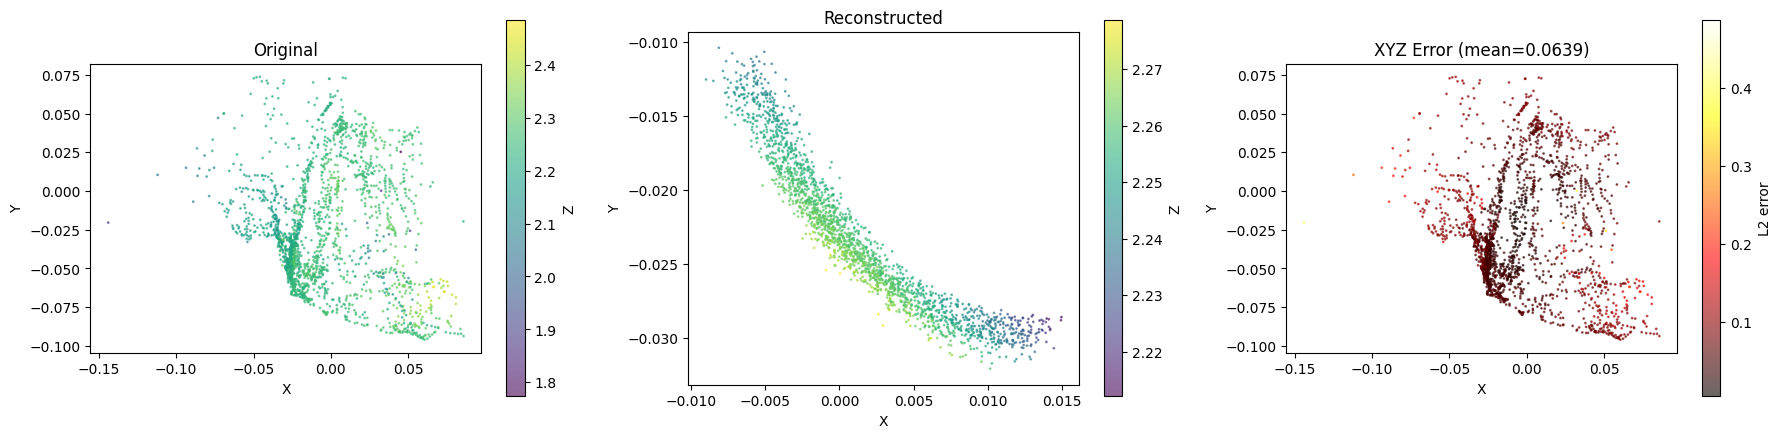

In [9]:
# Visualize: original vs reconstructed XYZ
points
orig = points[0].cpu().numpy()      # [2048, 14]
rec = recon[0].cpu().numpy()         # [2048, 14]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top-down view (X vs Y, colored by Z)
for ax, data, title in [(axes[0], orig, 'Original'), (axes[1], rec, 'Reconstructed')]:
    sc = ax.scatter(data[:, 0], data[:, 1], c=data[:, 2], cmap='viridis', s=1, alpha=0.6)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title)
    ax.set_aspect('equal')
    plt.colorbar(sc, ax=ax, shrink=0.8, label='Z')

# Error magnitude per point
error = np.sqrt(((orig[:, :3] - rec[:, :3]) ** 2).sum(axis=1))
sc = axes[2].scatter(orig[:, 0], orig[:, 1], c=error, cmap='hot', s=1, alpha=0.6)
axes[2].set_xlabel('X')
axes[2].set_ylabel('Y')
axes[2].set_title(f'XYZ Error (mean={error.mean():.4f})')
axes[2].set_aspect('equal')
plt.colorbar(sc, ax=axes[2], shrink=0.8, label='L2 error')

plt.tight_layout()
plt.savefig(os.path.join(GWM_PATH, 'notebooks', 'ae_reconstruction_xyz.png'), dpi=150)
plt.show()

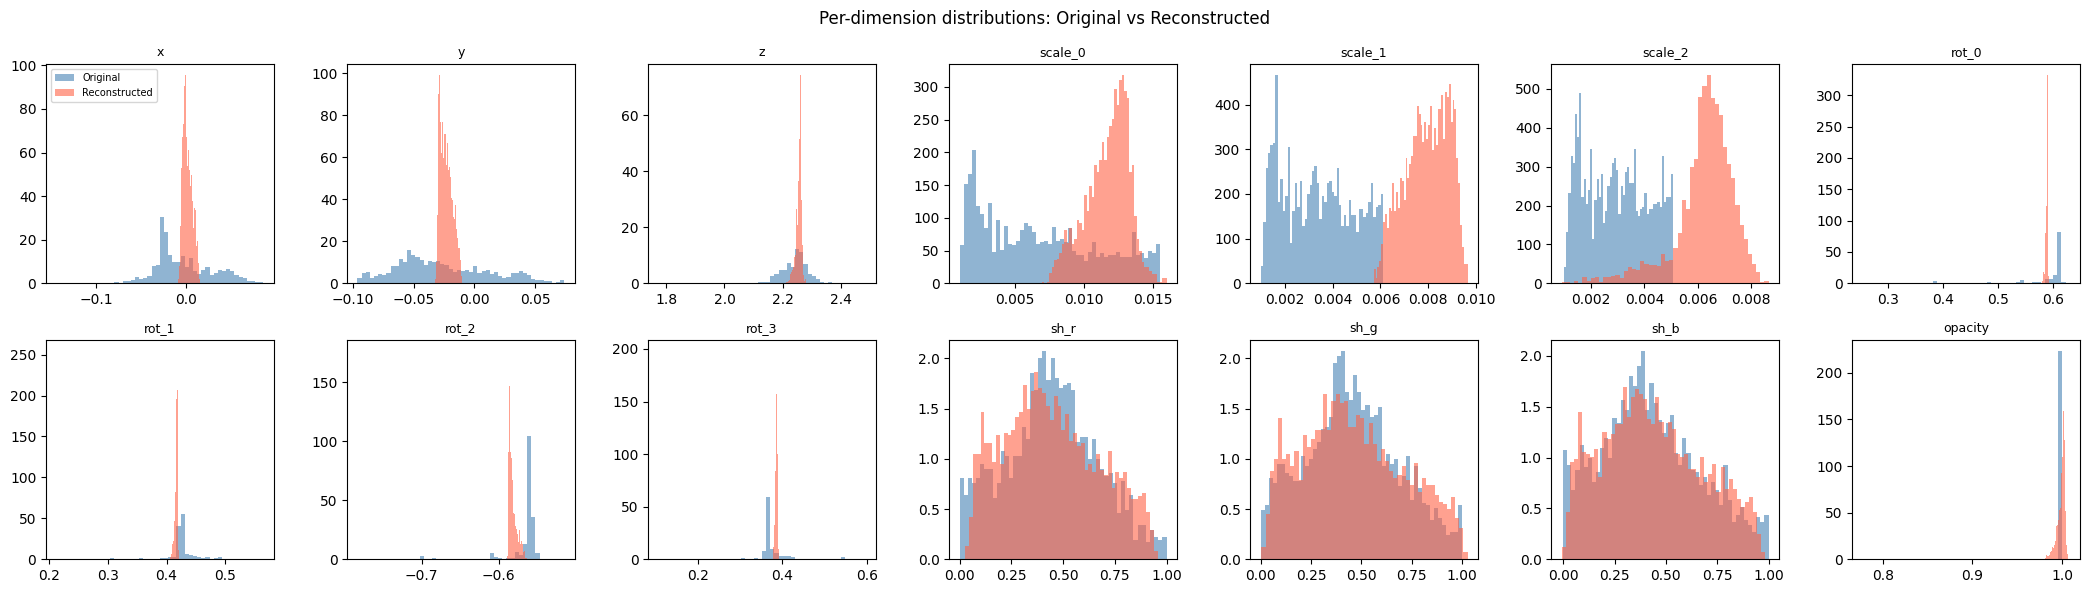

In [10]:
# Per-dimension histograms: original (blue) vs reconstructed (red)
fig, axes = plt.subplots(2, 7, figsize=(21, 6))
axes = axes.flatten()

for d in range(14):
    ax = axes[d]
    ax.hist(orig[:, d], bins=50, alpha=0.6, color='steelblue', label='Original', density=True)
    ax.hist(rec[:, d], bins=50, alpha=0.6, color='tomato', label='Reconstructed', density=True)
    ax.set_title(dim_labels[d], fontsize=9)
    if d == 0:
        ax.legend(fontsize=7)

plt.suptitle('Per-dimension distributions: Original vs Reconstructed', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(GWM_PATH, 'notebooks', 'ae_reconstruction_histograms.png'), dpi=150)
plt.show()

## Checkpoint-10 Comparison

Comparing epoch 5 vs epoch 10 reconstruction to check if continued training improves quality at these low loss values.

In [11]:
# Load checkpoint-10 and compare reconstruction
model_10 = create_autoencoder(
    depth=4, dim=64, M=64, latent_dim=64, output_dim=14, N=2048, deterministic=True
).to(device)

ckpt10_path = os.path.join(GWM_PATH, 'logs', 'vae_single_gpu', 'checkpoint-10.pth')
ckpt10 = torch.load(ckpt10_path, map_location=device, weights_only=False)
model_10.load_state_dict(ckpt10['model'])
model_10.eval()
print(f'Loaded checkpoint from epoch {ckpt10["epoch"]}')

with torch.no_grad():
    recon_10 = model_10(points, points)['logits']

mse_10 = torch.nn.functional.mse_loss(recon_10, points).item()
per_dim_mse_10 = ((recon_10 - points) ** 2).mean(dim=(0, 1))

# Side-by-side comparison
print(f'{"Dimension":>10s}  {"ckpt-5":>10s}  {"ckpt-10":>10s}  {"delta":>10s}')
print('-' * 46)
for i, label in enumerate(dim_labels):
    v5 = per_dim_mse[i].item()
    v10 = per_dim_mse_10[i].item()
    delta = v10 - v5
    arrow = 'v' if delta < 0 else '^'
    print(f'{label:>10s}  {v5:10.6f}  {v10:10.6f}  {delta:+10.6f} {arrow}')
print('-' * 46)
print(f'{"Overall":>10s}  {mse:10.6f}  {mse_10:10.6f}  {mse_10 - mse:+10.6f} {"v" if mse_10 < mse else "^"}')

Loaded checkpoint from epoch 10
 Dimension      ckpt-5     ckpt-10       delta
----------------------------------------------
         x    0.000952    0.000253   -0.000699 v
         y    0.001462    0.000504   -0.000959 v
         z    0.002825    0.002327   -0.000498 v
   scale_0    0.000042    0.000027   -0.000016 v
   scale_1    0.000023    0.000028   +0.000005 ^
   scale_2    0.000014    0.000004   -0.000010 v
     rot_0    0.002100    0.001494   -0.000606 v
     rot_1    0.000820    0.000741   -0.000079 v
     rot_2    0.000883    0.000940   +0.000058 ^
     rot_3    0.001660    0.001126   -0.000534 v
      sh_r    0.001521    0.001001   -0.000519 v
      sh_g    0.001069    0.000761   -0.000308 v
      sh_b    0.001347    0.001473   +0.000126 ^
   opacity    0.000057    0.000074   +0.000017 ^
----------------------------------------------
   Overall    0.001055    0.000768   -0.000287 v


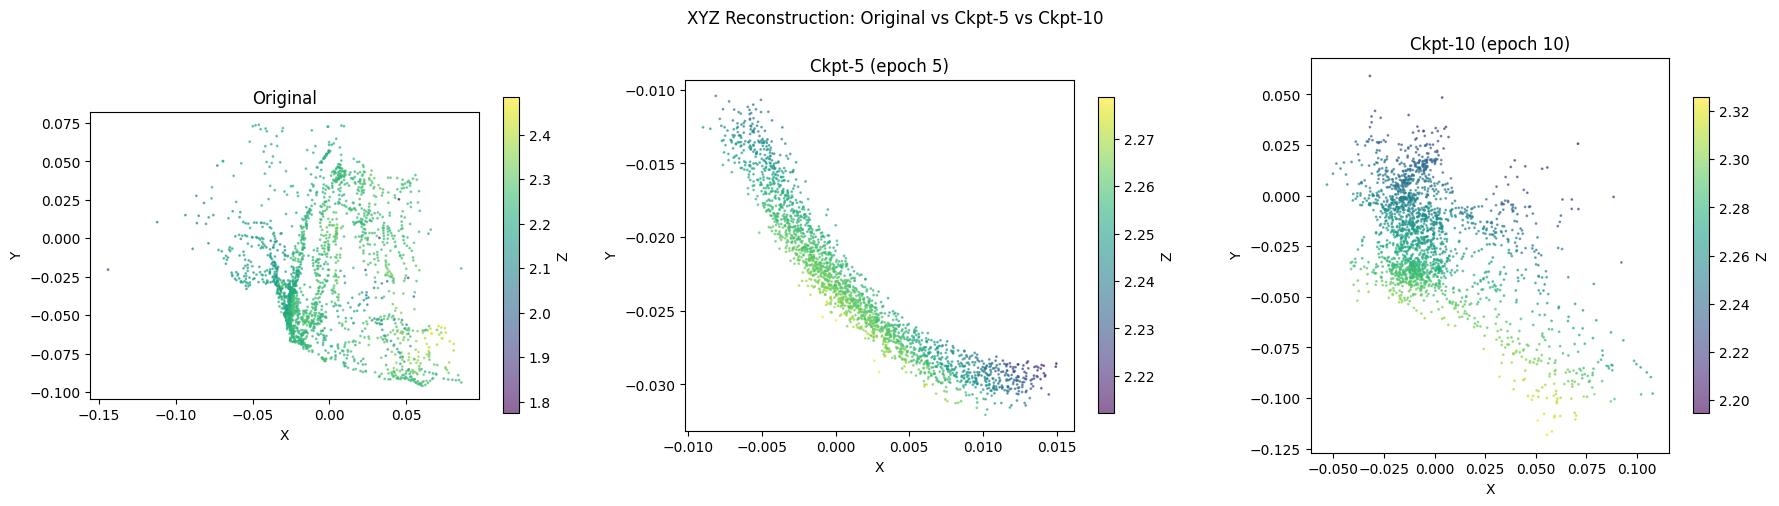

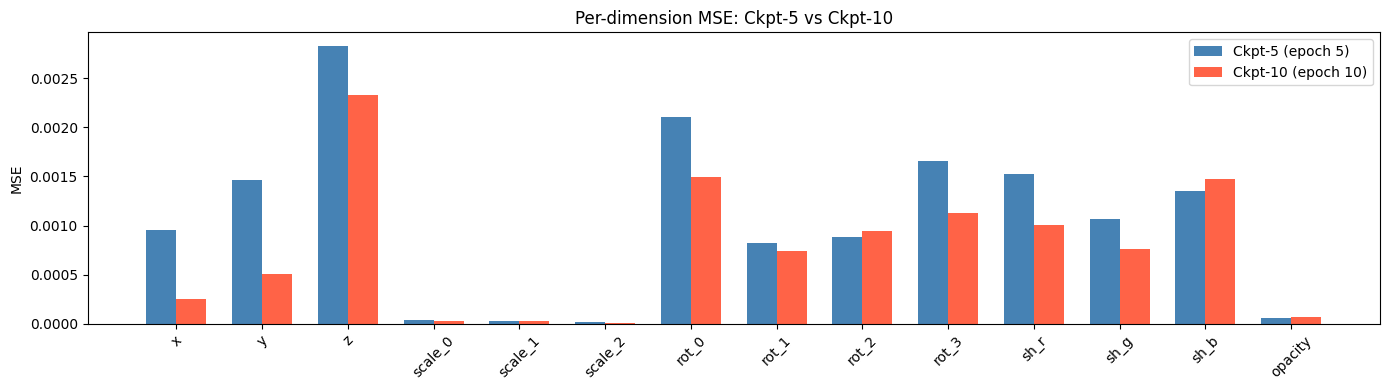

In [12]:
# Visual comparison: original vs ckpt-5 vs ckpt-10
rec_10 = recon_10[0].cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, data, title in [(axes[0], orig, 'Original'),
                         (axes[1], rec, 'Ckpt-5 (epoch 5)'),
                         (axes[2], rec_10, 'Ckpt-10 (epoch 10)')]:
    sc = ax.scatter(data[:, 0], data[:, 1], c=data[:, 2], cmap='viridis', s=1, alpha=0.6)
    ax.set_xlabel('X'); ax.set_ylabel('Y')
    ax.set_title(title); ax.set_aspect('equal')
    plt.colorbar(sc, ax=ax, shrink=0.8, label='Z')
plt.suptitle('XYZ Reconstruction: Original vs Ckpt-5 vs Ckpt-10')
plt.tight_layout()

# Per-dimension MSE bar chart
fig2, ax2 = plt.subplots(figsize=(14, 4))
x = np.arange(14)
w = 0.35
ax2.bar(x - w/2, per_dim_mse.cpu().numpy(), w, label='Ckpt-5 (epoch 5)', color='steelblue')
ax2.bar(x + w/2, per_dim_mse_10.cpu().numpy(), w, label='Ckpt-10 (epoch 10)', color='tomato')
ax2.set_xticks(x); ax2.set_xticklabels(dim_labels, rotation=45)
ax2.set_ylabel('MSE'); ax2.set_title('Per-dimension MSE: Ckpt-5 vs Ckpt-10')
ax2.legend()
plt.tight_layout()
plt.savefig(os.path.join(GWM_PATH, 'notebooks', 'ae_reconstruction_ckpt_comparison.png'), dpi=150)
plt.show()

## Full Checkpoint Progression Analysis (Epochs 0, 5, 10, 15, 19)

Evaluating all available checkpoints to track reconstruction quality improvement over 20 epochs.

In [13]:
# Load and evaluate all checkpoints (epochs 0, 5, 10, 15, 19)
from gaussianwm.encoder.models_ae import create_autoencoder

checkpoint_epochs = [0, 5, 10, 15, 19]
checkpoint_dir = os.path.join(GWM_PATH, 'logs', 'vae_single_gpu')

results = {
    'epochs': [],
    'overall_mse': [],
    'per_dim_mse': []  # List of [14] arrays
}

print(f"{'Epoch':>5s}  {'Overall MSE':>12s}  {'Status':>10s}")
print('-' * 35)

for epoch in checkpoint_epochs:
    ckpt_path = os.path.join(checkpoint_dir, f'checkpoint-{epoch}.pth')
    
    if not os.path.exists(ckpt_path):
        print(f'{epoch:>5d}  {"N/A":>12s}  {"MISSING":>10s}')
        continue
    
    # Create fresh model instance
    model_eval = create_autoencoder(
        depth=4, dim=64, M=64, latent_dim=64, output_dim=14, N=2048, deterministic=True
    ).to(device)
    
    # Load checkpoint
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model_eval.load_state_dict(ckpt['model'])
    model_eval.eval()
    
    # Run reconstruction on same point cloud used above
    with torch.no_grad():
        recon_eval = model_eval(points, points)['logits']
    
    # Compute metrics
    overall_mse_val = torch.nn.functional.mse_loss(recon_eval, points).item()
    per_dim = ((recon_eval - points) ** 2).mean(dim=(0, 1)).cpu().numpy()
    
    # Store results
    results['epochs'].append(epoch)
    results['overall_mse'].append(overall_mse_val)
    results['per_dim_mse'].append(per_dim)
    
    print(f'{epoch:>5d}  {overall_mse_val:>12.6f}  {"✓":>10s}')
    
    # Cleanup
    del model_eval, ckpt, recon_eval
    torch.cuda.empty_cache()

print('-' * 35)
print(f"Evaluated {len(results['epochs'])} checkpoints successfully")

Epoch   Overall MSE      Status
-----------------------------------
    0      0.013054           ✓
    5      0.001055           ✓
   10      0.000768           ✓
   15      0.000422           ✓
   19      0.000314           ✓
-----------------------------------
Evaluated 5 checkpoints successfully


In [14]:
# Extract and prepare variables for visualization
epochs_arr = np.array(results['epochs'])
overall_mse_arr = np.array(results['overall_mse'])
per_dim_array = np.array(results['per_dim_mse'])  # Shape: [num_epochs, 14]

# Compute improvement metrics
initial_mse = per_dim_array[0]  # Epoch 0
final_mse = per_dim_array[-1]   # Final epoch
improvement = initial_mse - final_mse
improvement_pct = (improvement / initial_mse) * 100

In [14]:
# Summary table: All checkpoints side-by-side
print("=" * 100)
print("FULL CHECKPOINT EVALUATION SUMMARY")
print("=" * 100)

# Header
header = f"{'Dimension':>10s}  "
for epoch in epochs_arr:
    header += f"{'Epoch ' + str(epoch):>12s}  "
header += f"{'Improvement':>12s}"
print(header)
print("-" * 100)

# Per-dimension rows
for d, label in enumerate(dim_labels):
    row = f"{label:>10s}  "
    for i in range(len(epochs_arr)):
        row += f"{per_dim_array[i, d]:>12.6f}  "
    # Improvement from first to last
    imp = per_dim_array[0, d] - per_dim_array[-1, d]
    imp_pct = (imp / per_dim_array[0, d]) * 100
    row += f"{imp_pct:>11.1f}%"
    print(row)

print("-" * 100)

# Overall MSE row
overall_row = f"{'OVERALL':>10s}  "
for mse_val in overall_mse_arr:
    overall_row += f"{mse_val:>12.6f}  "
overall_imp_pct = (overall_mse_arr[0] - overall_mse_arr[-1]) / overall_mse_arr[0] * 100
overall_row += f"{overall_imp_pct:>11.1f}%"
print(overall_row)
print("=" * 100)

# Key insights
print("\nKEY INSIGHTS:")
print(f"  • Overall MSE improved by {overall_imp_pct:.1f}% from epoch {epochs_arr[0]} to {epochs_arr[-1]}")
print(f"  • Best performing dimensions: {', '.join([dim_labels[i] for i in np.argsort(final_mse)[:3]])}")
print(f"  • Most improved dimensions: {', '.join([dim_labels[i] for i in np.argsort(improvement_pct)[-3:][::-1]])}")
print(f"  • Dimensions needing attention: {', '.join([dim_labels[i] for i in np.argsort(final_mse)[-3:][::-1]])}")

FULL CHECKPOINT EVALUATION SUMMARY
 Dimension       Epoch 0       Epoch 5      Epoch 10      Epoch 15      Epoch 19   Improvement
----------------------------------------------------------------------------------------------------
         x      0.000510      0.000304      0.000303      0.000114      0.000117         77.1%
         y      0.006427      0.005235      0.001103      0.000311      0.000155         97.6%
         z      0.004139      0.002232      0.001034      0.000699      0.000349         91.6%
   scale_0      0.000085      0.000094      0.000013      0.000018      0.000015         82.0%
   scale_1      0.000442      0.000032      0.000006      0.000003      0.000002         99.4%
   scale_2      0.000009      0.000006      0.000013      0.000003      0.000011        -18.0%
     rot_0      0.001635      0.001438      0.001009      0.001018      0.000485         70.3%
     rot_1      0.000767      0.000600      0.000458      0.000502      0.000554         27.7%
     rot_

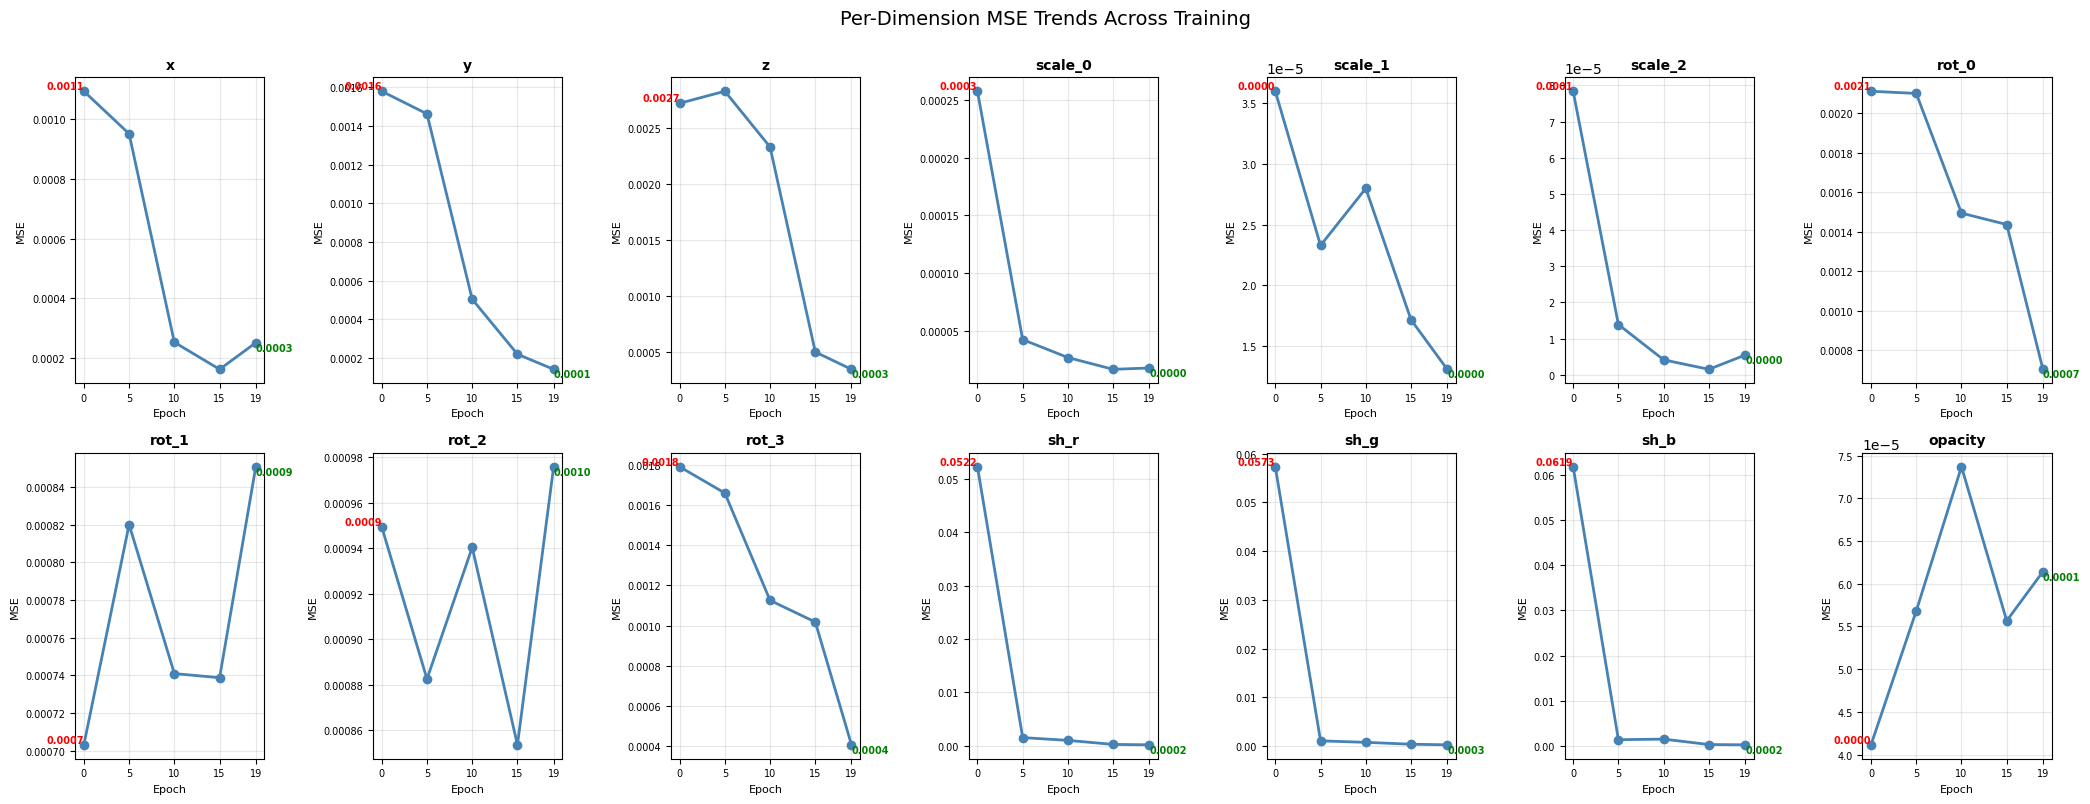

In [15]:
# Plot 4: Per-dimension MSE trends (line plot for each dimension)
fig, axes = plt.subplots(2, 7, figsize=(21, 8))
axes = axes.flatten()

for d in range(14):
    ax = axes[d]
    dim_mse_over_time = per_dim_array[:, d]
    
    ax.plot(epochs_arr, dim_mse_over_time, 'o-', linewidth=2, markersize=6, color='steelblue')
    ax.set_title(dim_labels[d], fontsize=10, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=8)
    ax.set_ylabel('MSE', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(epochs_arr)
    ax.tick_params(axis='both', which='major', labelsize=7)
    
    # Annotate start and end values
    ax.text(epochs_arr[0], dim_mse_over_time[0], f'{dim_mse_over_time[0]:.4f}',
            fontsize=7, ha='right', va='bottom', color='red', fontweight='bold')
    ax.text(epochs_arr[-1], dim_mse_over_time[-1], f'{dim_mse_over_time[-1]:.4f}',
            fontsize=7, ha='left', va='top', color='green', fontweight='bold')

plt.suptitle('Per-Dimension MSE Trends Across Training', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(GWM_PATH, 'notebooks', 'ae_per_dim_trends.png'), dpi=150)
plt.show()

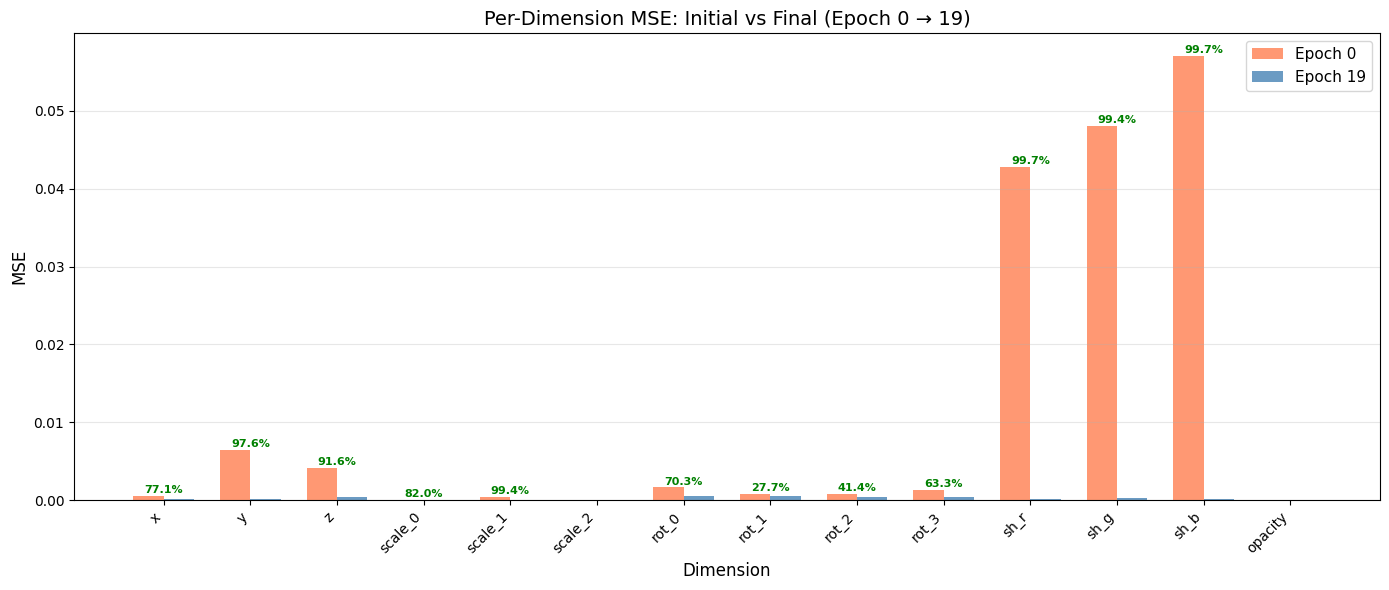


Per-dimension improvement (epoch 0 → 19):
 Dimension     Initial       Final       Δ abs       Δ %
--------------------------------------------------------
         x    0.000510    0.000117    0.000393     77.1%
         y    0.006427    0.000155    0.006272     97.6%
         z    0.004139    0.000349    0.003790     91.6%
   scale_0    0.000085    0.000015    0.000070     82.0%
   scale_1    0.000442    0.000002    0.000440     99.4%
   scale_2    0.000009    0.000011   -0.000002    -18.0%
     rot_0    0.001635    0.000485    0.001150     70.3%
     rot_1    0.000767    0.000554    0.000212     27.7%
     rot_2    0.000809    0.000474    0.000335     41.4%
     rot_3    0.001298    0.000476    0.000822     63.3%
      sh_r    0.042785    0.000137    0.042648     99.7%
      sh_g    0.048026    0.000293    0.047734     99.4%
      sh_b    0.057107    0.000150    0.056957     99.7%
   opacity    0.000012    0.000021   -0.000010    -83.1%


In [16]:
# Plot 3: Per-dimension improvement (epoch 0 vs final epoch)
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(14)
width = 0.35

bars1 = ax.bar(x - width/2, initial_mse, width, label=f'Epoch {epochs_arr[0]}', color='coral', alpha=0.8)
bars2 = ax.bar(x + width/2, final_mse, width, label=f'Epoch {epochs_arr[-1]}', color='steelblue', alpha=0.8)

ax.set_xlabel('Dimension', fontsize=12)
ax.set_ylabel('MSE', fontsize=12)
ax.set_title(f'Per-Dimension MSE: Initial vs Final (Epoch {epochs_arr[0]} → {epochs_arr[-1]})', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(dim_labels, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

# Add improvement percentage labels above bars
for i, (imp, pct) in enumerate(zip(improvement, improvement_pct)):
    if imp > 0:  # Only show if there was improvement
        ax.text(i, max(initial_mse[i], final_mse[i]) + 0.0001, f'{pct:.1f}%',
                ha='center', va='bottom', fontsize=8, color='green', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(GWM_PATH, 'notebooks', 'ae_per_dim_comparison.png'), dpi=150)
plt.show()

print(f"\nPer-dimension improvement (epoch {epochs_arr[0]} → {epochs_arr[-1]}):")
print(f"{'Dimension':>10s}  {'Initial':>10s}  {'Final':>10s}  {'Δ abs':>10s}  {'Δ %':>8s}")
print('-' * 56)
for i, label in enumerate(dim_labels):
    print(f'{label:>10s}  {initial_mse[i]:>10.6f}  {final_mse[i]:>10.6f}  {improvement[i]:>10.6f}  {improvement_pct[i]:>7.1f}%')

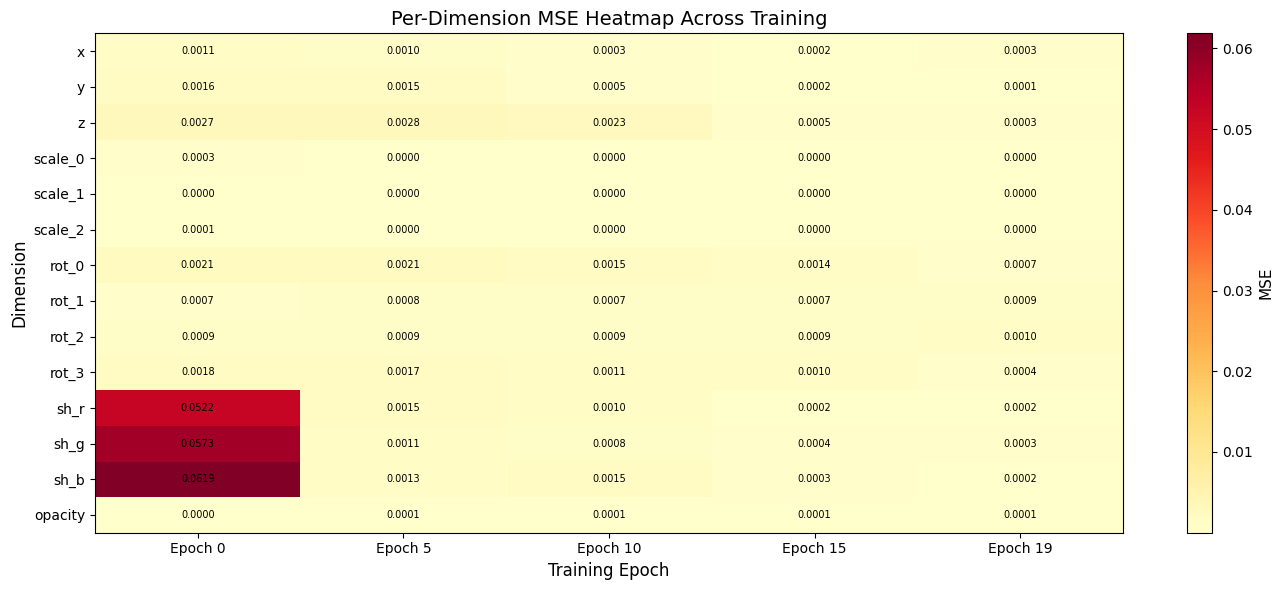

In [16]:
# Plot 2: Per-dimension MSE heatmap across epochs
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(per_dim_array.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')

# Set ticks and labels
ax.set_xticks(range(len(epochs_arr)))
ax.set_xticklabels([f'Epoch {e}' for e in epochs_arr])
ax.set_yticks(range(14))
ax.set_yticklabels(dim_labels)
ax.set_xlabel('Training Epoch', fontsize=12)
ax.set_ylabel('Dimension', fontsize=12)
ax.set_title('Per-Dimension MSE Heatmap Across Training', fontsize=14)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('MSE', fontsize=11)

# Annotate cells with values
for i in range(len(epochs_arr)):
    for j in range(14):
        text = ax.text(i, j, f'{per_dim_array[i, j]:.4f}',
                      ha='center', va='center', color='black', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(GWM_PATH, 'notebooks', 'ae_per_dim_heatmap.png'), dpi=150)
plt.show()

## Epoch 19 Final Reconstruction Visualization

Detailed visual analysis of the best checkpoint (epoch 19) - showing what the AE has learned to reconstruct.

In [18]:
# Load epoch 19 checkpoint (best performance)
model_19 = create_autoencoder(
    depth=4, dim=64, M=64, latent_dim=64, output_dim=14, N=2048, deterministic=True
).to(device)

ckpt19_path = os.path.join(GWM_PATH, 'logs', 'vae_single_gpu', 'checkpoint-19.pth')
ckpt19 = torch.load(ckpt19_path, map_location=device, weights_only=False)
model_19.load_state_dict(ckpt19['model'])
model_19.eval()
print(f'Loaded checkpoint from epoch {ckpt19["epoch"]}')

with torch.no_grad():
    recon_19 = model_19(points, points)['logits']

mse_19 = torch.nn.functional.mse_loss(recon_19, points).item()
per_dim_mse_19 = ((recon_19 - points) ** 2).mean(dim=(0, 1))

print(f'\nEpoch 19 Overall MSE: {mse_19:.6f}')
print('\nPer-dimension MSE:')
for i, label in enumerate(dim_labels):
    print(f'  {label:>8s}: {per_dim_mse_19[i].item():.6f}')

# Prepare numpy arrays for visualization
orig_19 = points[0].cpu().numpy()      # [2048, 14]
rec_19 = recon_19[0].cpu().numpy()     # [2048, 14]

Loaded checkpoint from epoch 19

Epoch 19 Overall MSE: 0.000314

Per-dimension MSE:
         x: 0.000251
         y: 0.000142
         z: 0.000342
   scale_0: 0.000018
   scale_1: 0.000013
   scale_2: 0.000005
     rot_0: 0.000704
     rot_1: 0.000851
     rot_2: 0.000976
     rot_3: 0.000407
      sh_r: 0.000167
      sh_g: 0.000252
      sh_b: 0.000210
   opacity: 0.000061


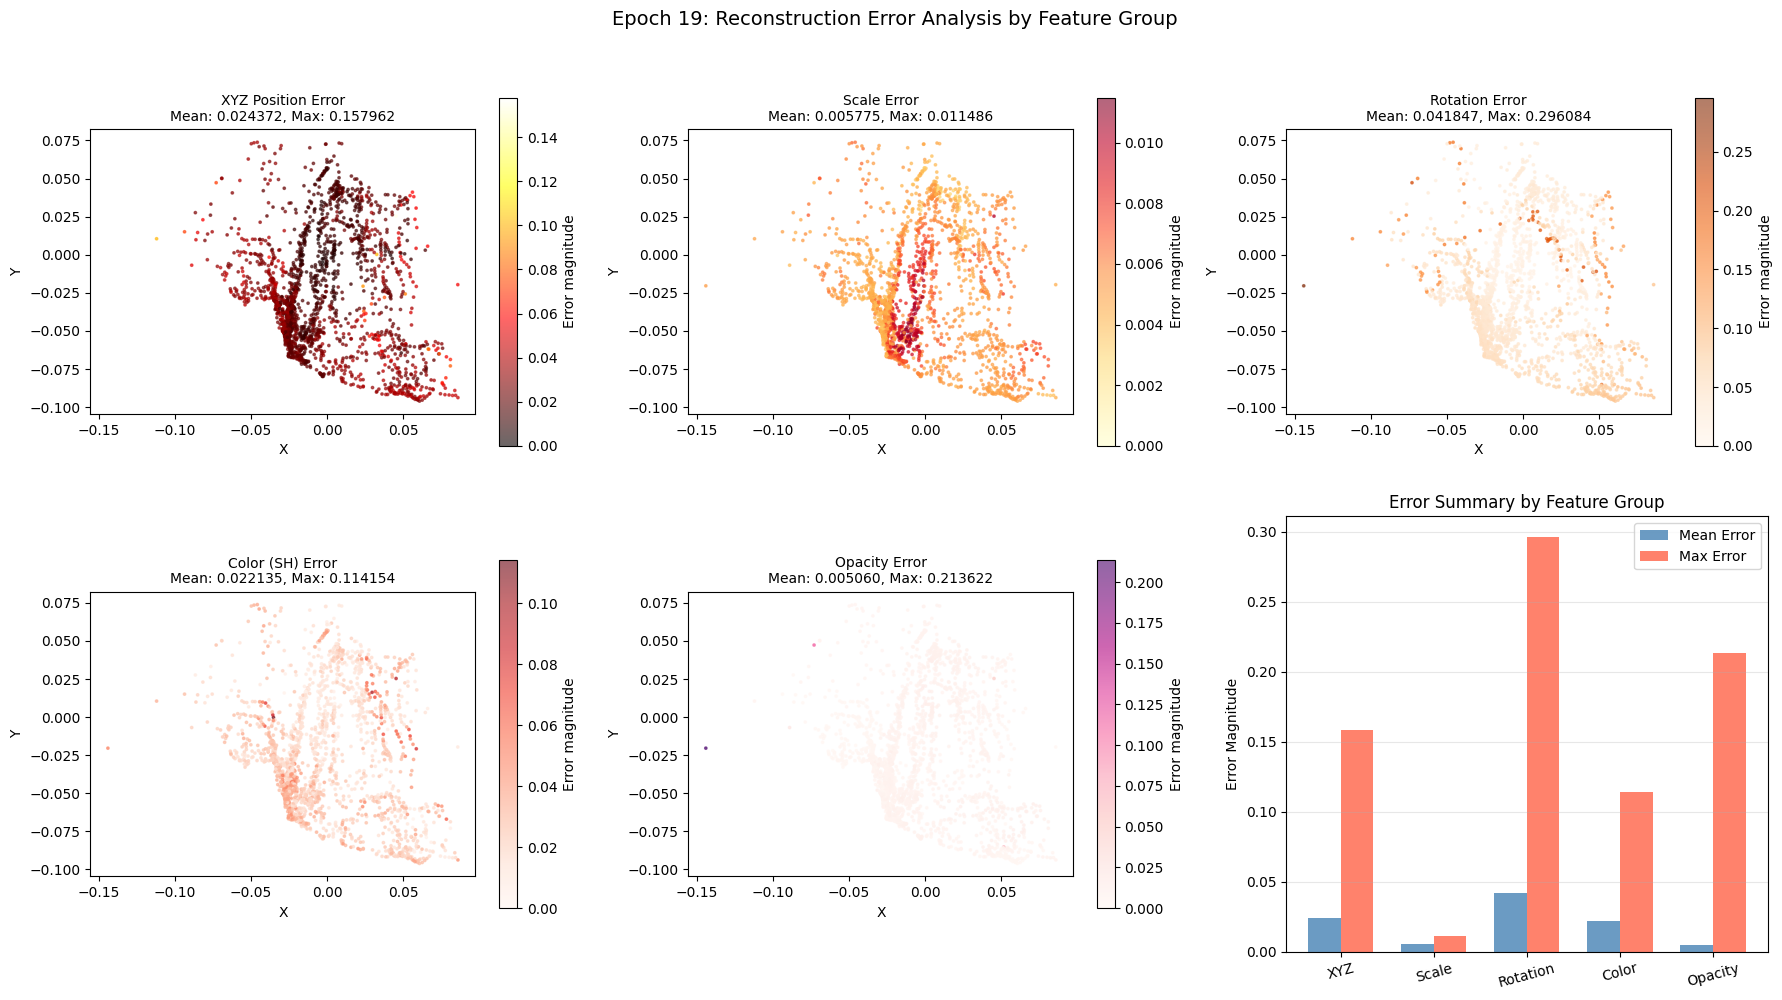


Error Summary by Feature Group:
       Group    Mean Error     Max Error     Std Error
------------------------------------------------------
         XYZ      0.024372      0.157962      0.011861
       Scale      0.005775      0.011486      0.001709
    Rotation      0.041847      0.296084      0.034443
       Color      0.022135      0.114154      0.011794
     Opacity      0.005060      0.213622      0.005984


In [19]:
# Visualization 4: Error analysis - where does the reconstruction fail?
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Calculate per-point errors for different feature groups
xyz_error = np.sqrt(((orig_19[:, :3] - rec_19[:, :3]) ** 2).sum(axis=1))
scale_error = np.sqrt(((orig_19[:, 3:6] - rec_19[:, 3:6]) ** 2).sum(axis=1))
rot_error = np.sqrt(((orig_19[:, 6:10] - rec_19[:, 6:10]) ** 2).sum(axis=1))
color_error = np.sqrt(((orig_19[:, 10:13] - rec_19[:, 10:13]) ** 2).sum(axis=1))
opacity_error = np.abs(orig_19[:, 13] - rec_19[:, 13])

errors = [
    (xyz_error, 'XYZ Position Error', 'hot'),
    (scale_error, 'Scale Error', 'YlOrRd'),
    (rot_error, 'Rotation Error', 'Oranges'),
    (color_error, 'Color (SH) Error', 'Reds'),
    (opacity_error, 'Opacity Error', 'RdPu'),
]

for idx, (error_vals, title, cmap) in enumerate(errors):
    ax = axes[idx // 3, idx % 3]
    
    sc = ax.scatter(orig_19[:, 0], orig_19[:, 1], c=error_vals, 
                    cmap=cmap, s=3, alpha=0.6, vmin=0)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'{title}\nMean: {error_vals.mean():.6f}, Max: {error_vals.max():.6f}', 
                 fontsize=10)
    ax.set_aspect('equal')
    plt.colorbar(sc, ax=ax, shrink=0.8, label='Error magnitude')

# Overall error summary (bar chart)
ax = axes[1, 2]
feature_groups = ['XYZ', 'Scale', 'Rotation', 'Color', 'Opacity']
mean_errors = [e.mean() for e, _, _ in errors]
max_errors = [e.max() for e, _, _ in errors]

x = np.arange(len(feature_groups))
width = 0.35
ax.bar(x - width/2, mean_errors, width, label='Mean Error', color='steelblue', alpha=0.8)
ax.bar(x + width/2, max_errors, width, label='Max Error', color='tomato', alpha=0.8)
ax.set_ylabel('Error Magnitude')
ax.set_title('Error Summary by Feature Group')
ax.set_xticks(x)
ax.set_xticklabels(feature_groups, rotation=15)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Epoch 19: Reconstruction Error Analysis by Feature Group', fontsize=14, y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(GWM_PATH, 'notebooks', 'ae_epoch19_error_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nError Summary by Feature Group:")
print(f"{'Group':>12s}  {'Mean Error':>12s}  {'Max Error':>12s}  {'Std Error':>12s}")
print('-' * 54)
for (error_vals, title, _), name in zip(errors, feature_groups):
    print(f'{name:>12s}  {error_vals.mean():>12.6f}  {error_vals.max():>12.6f}  {error_vals.std():>12.6f}')

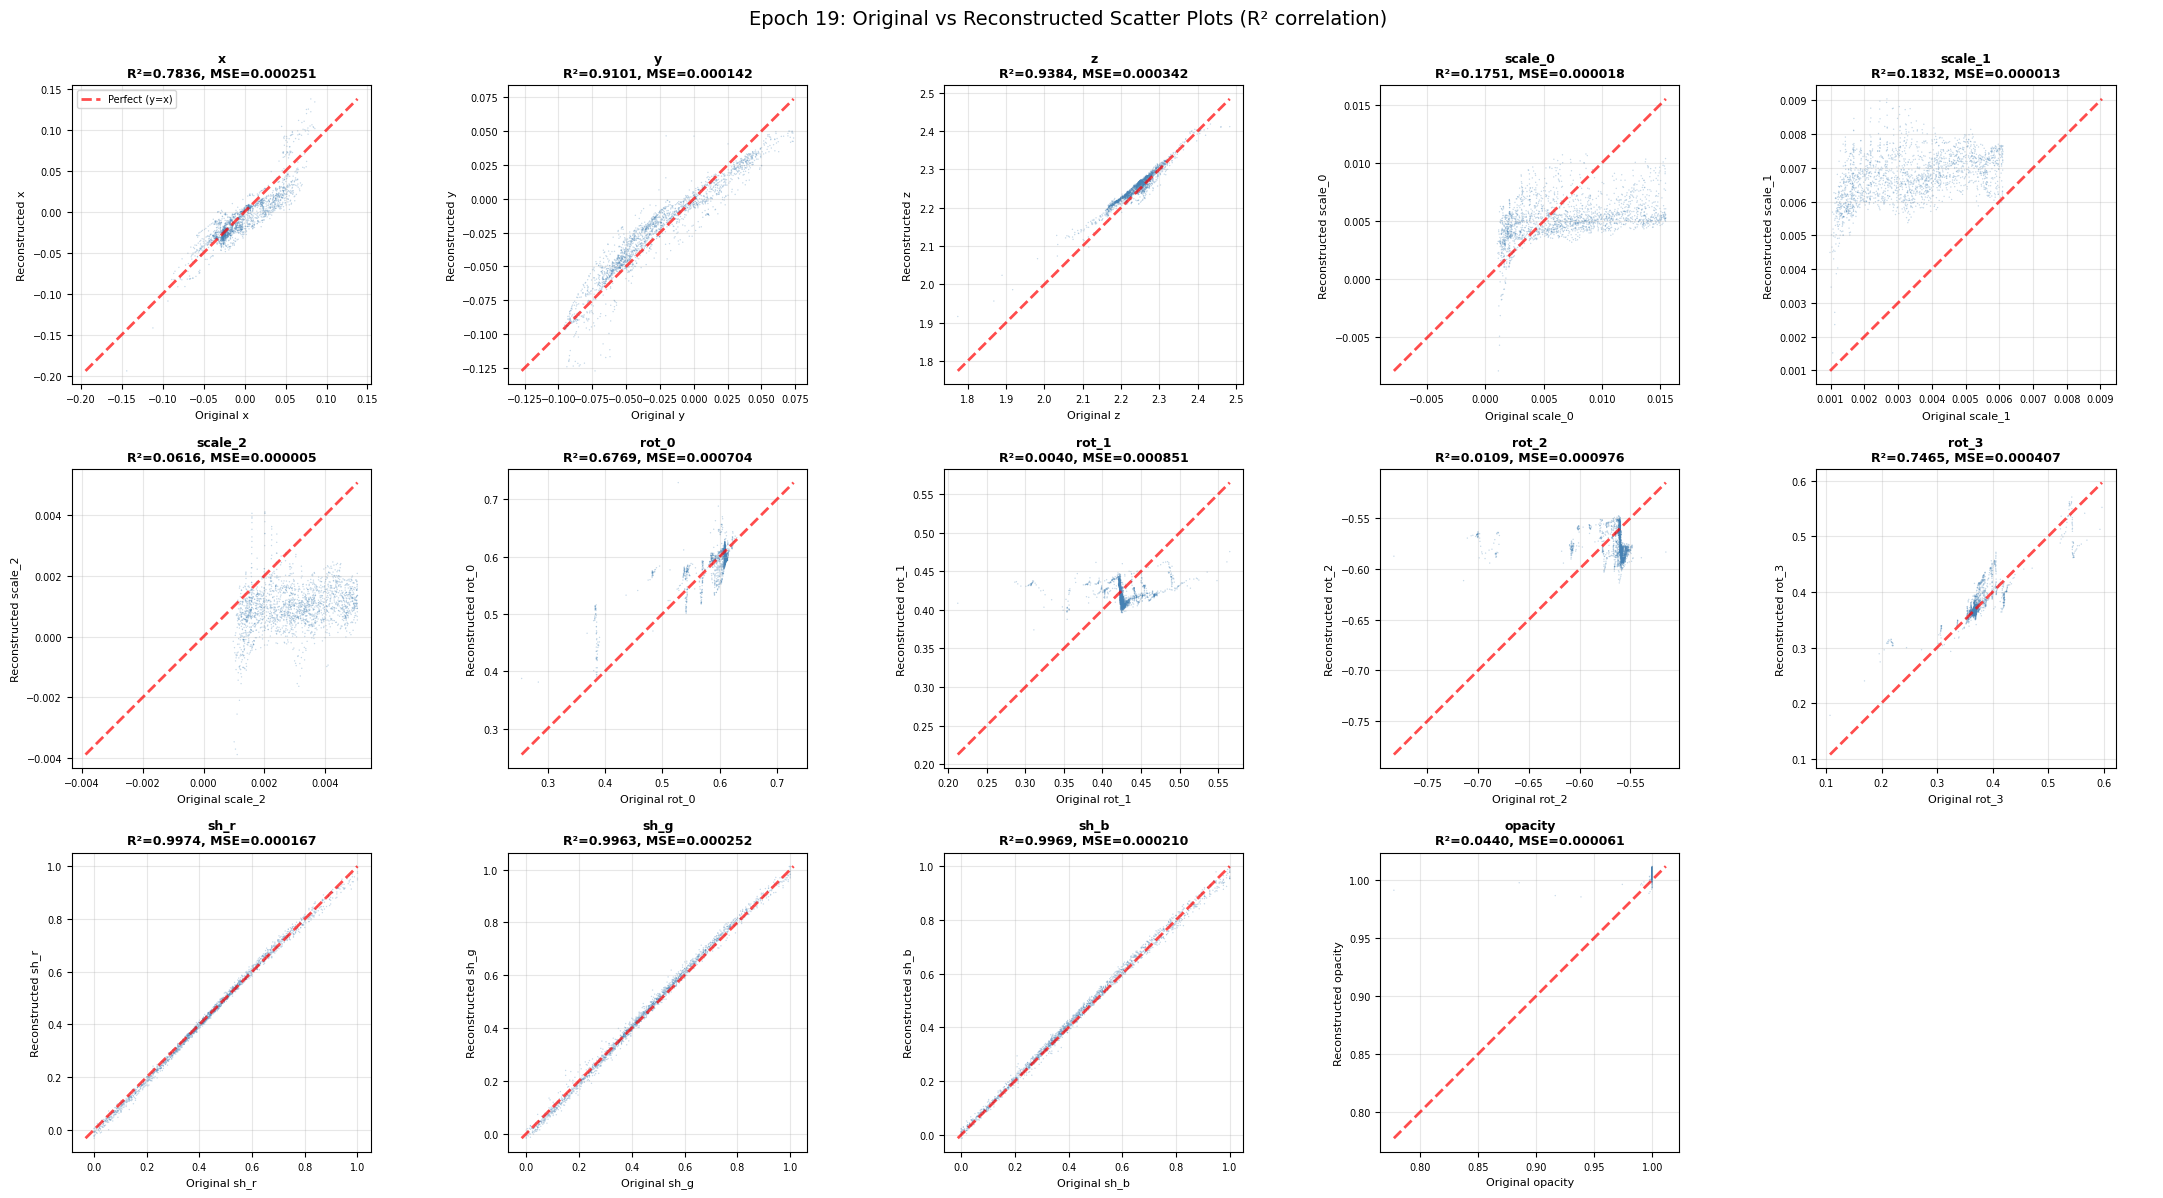


R² correlation scores (1.0 = perfect reconstruction):
 Dimension        R²         MSE
--------------------------------
         x  0.783555    0.000251
         y  0.910087    0.000142
         z  0.938404    0.000342
   scale_0  0.175070    0.000018
   scale_1  0.183213    0.000013
   scale_2  0.061553    0.000005
     rot_0  0.676923    0.000704
     rot_1  0.004028    0.000851
     rot_2  0.010926    0.000976
     rot_3  0.746506    0.000407
      sh_r  0.997410    0.000167
      sh_g  0.996314    0.000252
      sh_b  0.996926    0.000210
   opacity  0.044040    0.000061


In [20]:
# Visualization 3: Scatter plots comparing original vs reconstructed for each dimension
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()

for d in range(14):
    ax = axes[d]
    
    # Scatter plot: original vs reconstructed
    ax.scatter(orig_19[:, d], rec_19[:, d], s=1, alpha=0.3, c='steelblue', edgecolors='none')
    
    # Perfect reconstruction line (y=x)
    min_val = min(orig_19[:, d].min(), rec_19[:, d].min())
    max_val = max(orig_19[:, d].max(), rec_19[:, d].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, alpha=0.7, label='Perfect (y=x)')
    
    # Compute R² correlation
    correlation = np.corrcoef(orig_19[:, d], rec_19[:, d])[0, 1]
    r_squared = correlation ** 2
    
    ax.set_xlabel(f'Original {dim_labels[d]}', fontsize=8)
    ax.set_ylabel(f'Reconstructed {dim_labels[d]}', fontsize=8)
    ax.set_title(f'{dim_labels[d]}\nR²={r_squared:.4f}, MSE={per_dim_mse_19[d].item():.6f}', 
                 fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    if d == 0:
        ax.legend(fontsize=7)

# Remove extra subplot
axes[14].axis('off')

plt.suptitle('Epoch 19: Original vs Reconstructed Scatter Plots (R² correlation)', 
             fontsize=14, y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(GWM_PATH, 'notebooks', 'ae_epoch19_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nR² correlation scores (1.0 = perfect reconstruction):")
print(f"{'Dimension':>10s}  {'R²':>8s}  {'MSE':>10s}")
print('-' * 32)
for d in range(14):
    corr = np.corrcoef(orig_19[:, d], rec_19[:, d])[0, 1]
    r2 = corr ** 2
    print(f'{dim_labels[d]:>10s}  {r2:>8.6f}  {per_dim_mse_19[d].item():>10.6f}')

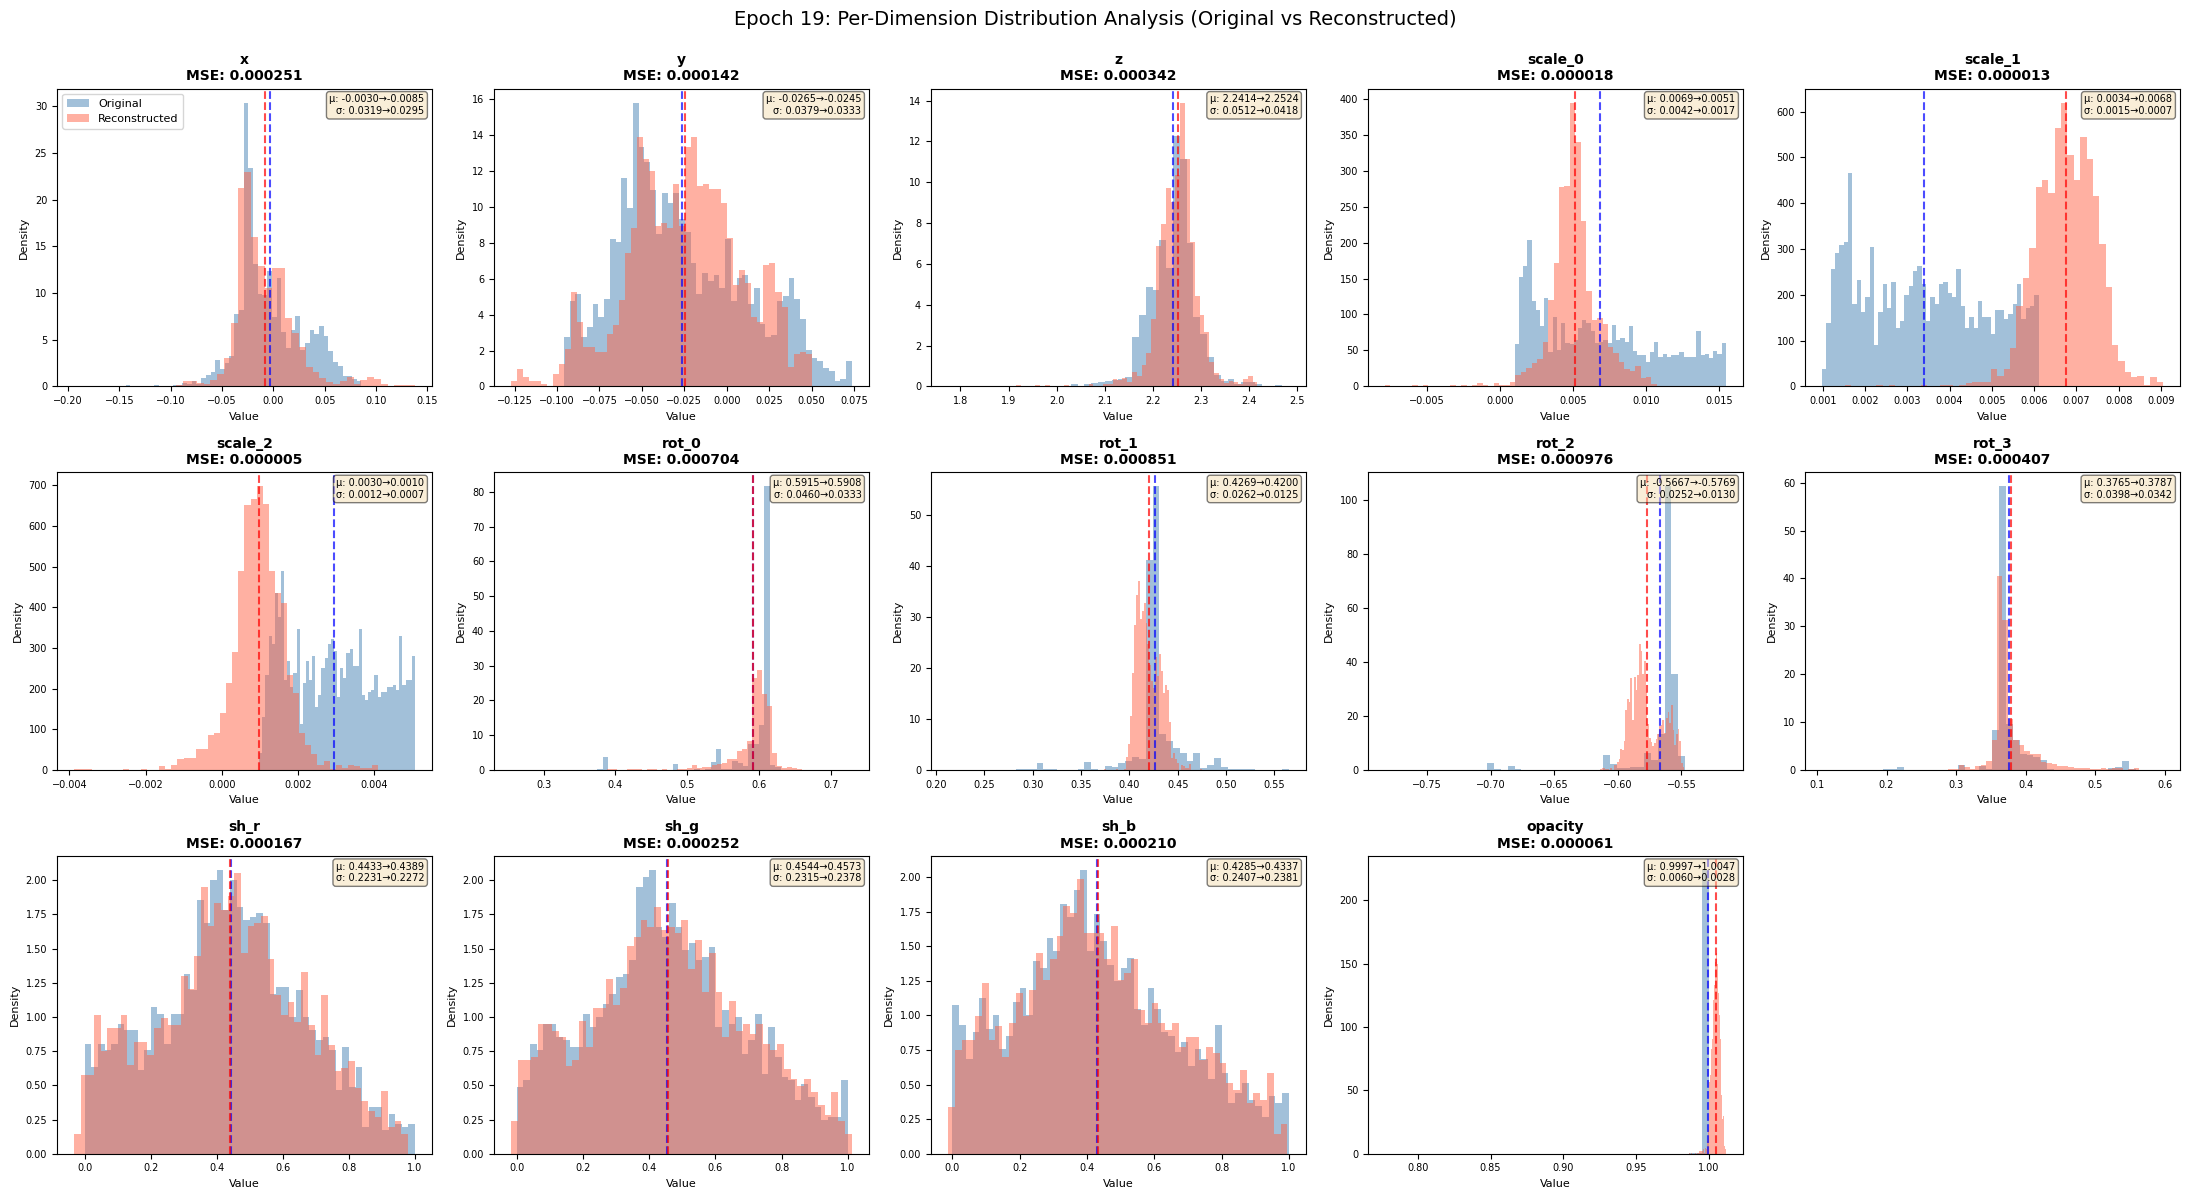

In [21]:
# Visualization 2: Per-dimension distribution comparison (all 14 dims)
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()

for d in range(14):
    ax = axes[d]
    
    # Histograms
    ax.hist(orig_19[:, d], bins=50, alpha=0.5, color='steelblue', 
            label='Original', density=True, edgecolor='none')
    ax.hist(rec_19[:, d], bins=50, alpha=0.5, color='tomato', 
            label='Reconstructed', density=True, edgecolor='none')
    
    # Statistics
    orig_mean = orig_19[:, d].mean()
    rec_mean = rec_19[:, d].mean()
    orig_std = orig_19[:, d].std()
    rec_std = rec_19[:, d].std()
    dim_mse = per_dim_mse_19[d].item()
    
    ax.axvline(orig_mean, color='blue', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axvline(rec_mean, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    
    ax.set_title(f'{dim_labels[d]}\nMSE: {dim_mse:.6f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    
    # Add stats text
    stats_text = f'μ: {orig_mean:.4f}→{rec_mean:.4f}\nσ: {orig_std:.4f}→{rec_std:.4f}'
    ax.text(0.98, 0.98, stats_text, transform=ax.transAxes, 
            fontsize=7, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))
    
    if d == 0:
        ax.legend(fontsize=8, loc='upper left')

# Remove extra subplot
axes[14].axis('off')

plt.suptitle('Epoch 19: Per-Dimension Distribution Analysis (Original vs Reconstructed)', 
             fontsize=14, y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(GWM_PATH, 'notebooks', 'ae_epoch19_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

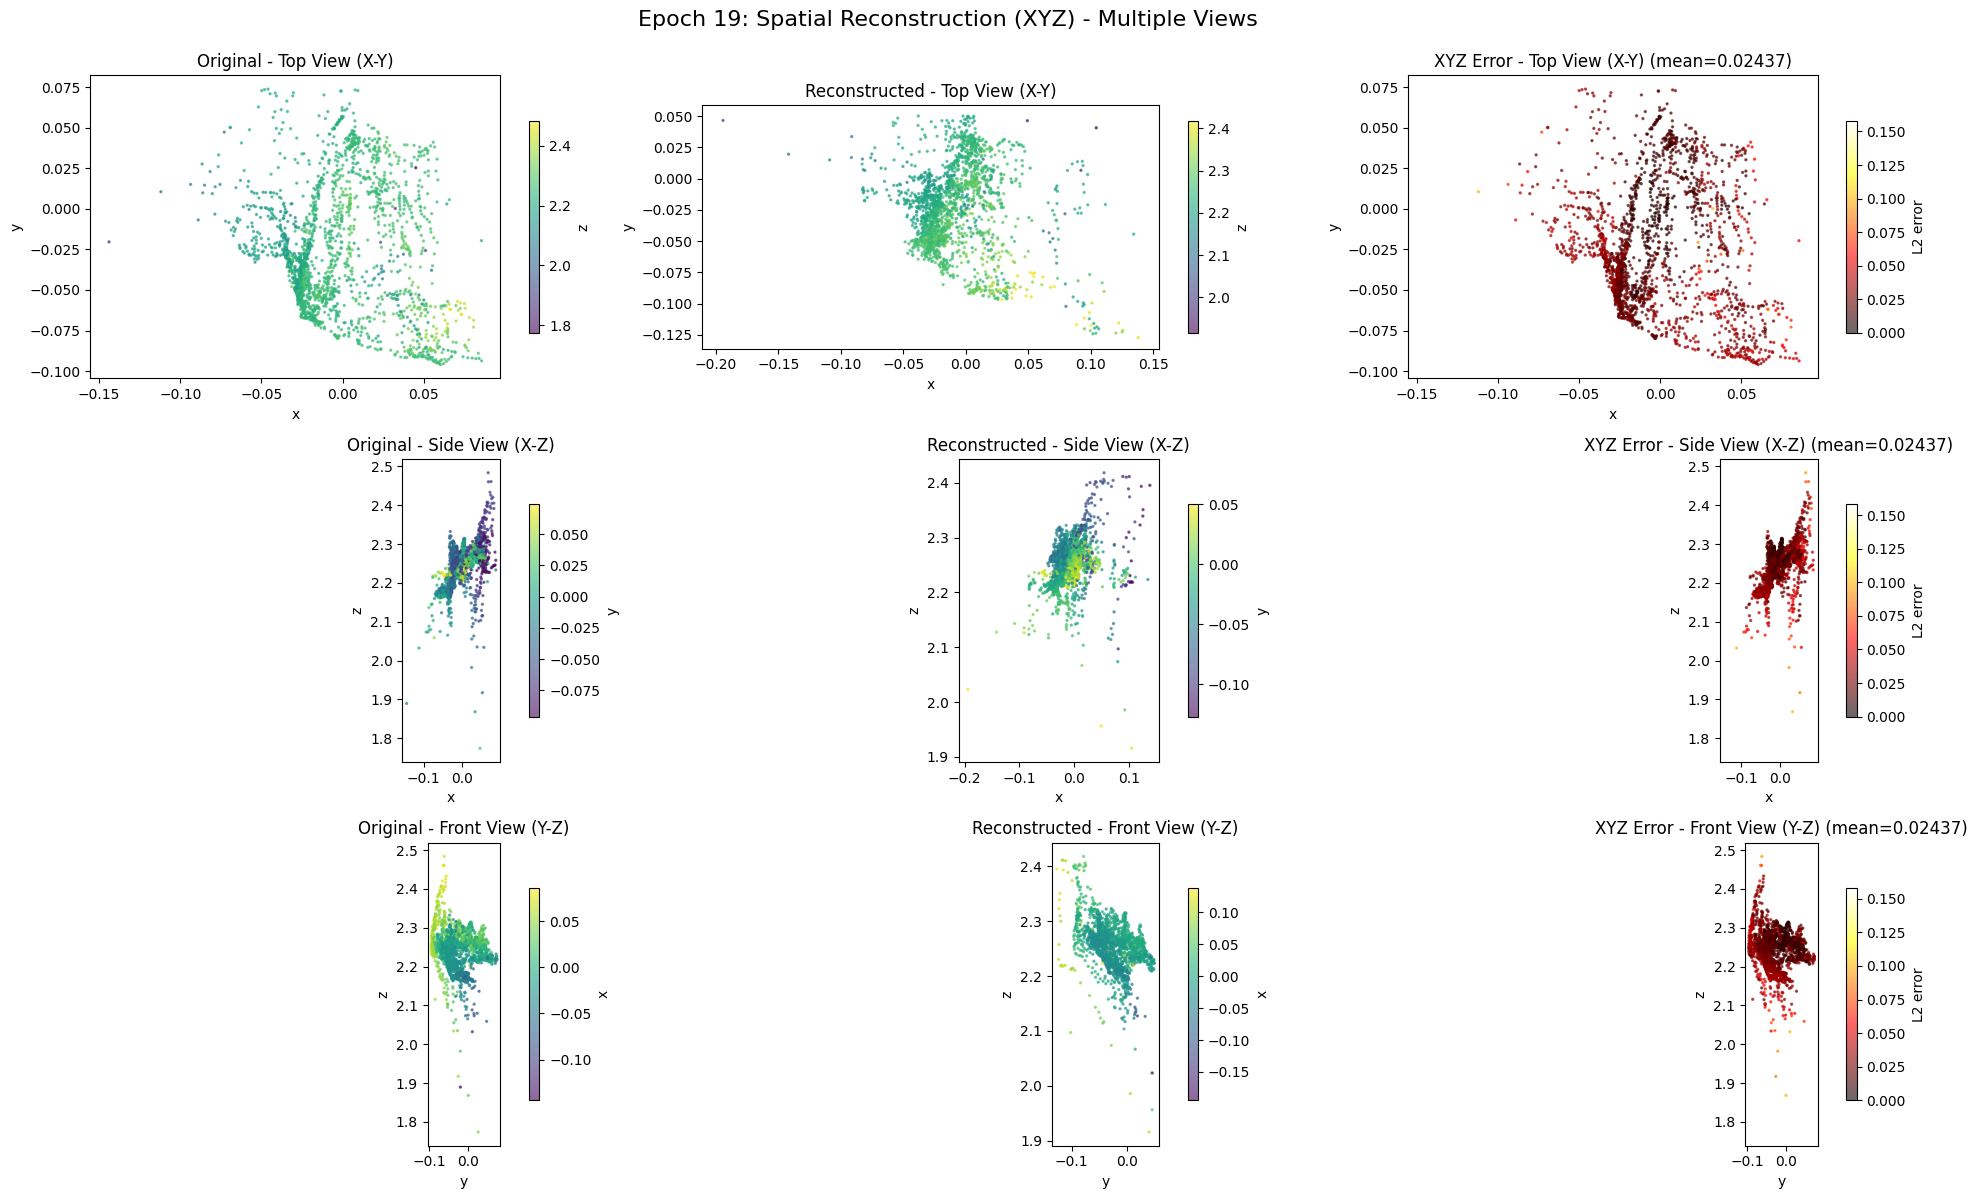

In [22]:
# Visualization 1: XYZ spatial reconstruction (3 views: top, side, front)
fig = plt.figure(figsize=(20, 12))

views = [
    ('Top View (X-Y)', 0, 1, 2),      # X vs Y, colored by Z
    ('Side View (X-Z)', 0, 2, 1),      # X vs Z, colored by Y
    ('Front View (Y-Z)', 1, 2, 0),     # Y vs Z, colored by X
]

for row_idx, (view_name, x_idx, y_idx, color_idx) in enumerate(views):
    # Original
    ax1 = plt.subplot(3, 3, row_idx * 3 + 1)
    sc1 = ax1.scatter(orig_19[:, x_idx], orig_19[:, y_idx], 
                      c=orig_19[:, color_idx], cmap='viridis', s=2, alpha=0.6)
    ax1.set_xlabel(dim_labels[x_idx])
    ax1.set_ylabel(dim_labels[y_idx])
    ax1.set_title(f'Original - {view_name}')
    ax1.set_aspect('equal')
    plt.colorbar(sc1, ax=ax1, shrink=0.7, label=dim_labels[color_idx])
    
    # Reconstructed
    ax2 = plt.subplot(3, 3, row_idx * 3 + 2)
    sc2 = ax2.scatter(rec_19[:, x_idx], rec_19[:, y_idx], 
                      c=rec_19[:, color_idx], cmap='viridis', s=2, alpha=0.6)
    ax2.set_xlabel(dim_labels[x_idx])
    ax2.set_ylabel(dim_labels[y_idx])
    ax2.set_title(f'Reconstructed - {view_name}')
    ax2.set_aspect('equal')
    plt.colorbar(sc2, ax=ax2, shrink=0.7, label=dim_labels[color_idx])
    
    # Error map
    ax3 = plt.subplot(3, 3, row_idx * 3 + 3)
    error_spatial = np.sqrt(((orig_19[:, :3] - rec_19[:, :3]) ** 2).sum(axis=1))
    sc3 = ax3.scatter(orig_19[:, x_idx], orig_19[:, y_idx], 
                      c=error_spatial, cmap='hot', s=2, alpha=0.6, vmin=0)
    ax3.set_xlabel(dim_labels[x_idx])
    ax3.set_ylabel(dim_labels[y_idx])
    ax3.set_title(f'XYZ Error - {view_name} (mean={error_spatial.mean():.5f})')
    ax3.set_aspect('equal')
    plt.colorbar(sc3, ax=ax3, shrink=0.7, label='L2 error')

plt.suptitle('Epoch 19: Spatial Reconstruction (XYZ) - Multiple Views', fontsize=16, y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(GWM_PATH, 'notebooks', 'ae_epoch19_spatial_views.png'), dpi=150, bbox_inches='tight')
plt.show()